In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from datetime import datetime

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_excel(r"C:\Users\Hp\Downloads\online+retail+ii\online_retail_II.xlsx")

In [8]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [9]:
df2= pd.read_excel(r"C:\Users\Hp\Downloads\online+retail+ii\online_retail_II.xlsx",sheet_name=1)

In [10]:
df2

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [11]:
df = pd.concat([df,df2],ignore_index=True)

In [12]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [13]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


(1067371, 8)

In [14]:
df.isnull().sum()
df.dropna(inplace=True)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['Price'] > 0]

In [19]:
df = df[~df['Invoice'].astype(str).str.contains('C')]

In [20]:
df['TotalAmount'] = df['Quantity'] * df['Price']

In [21]:
df.select_dtypes(['int','float'])

,Quantity,Price,Customer ID,TotalAmount
0,12,6.95,13085.0,83.40
1,12,6.75,13085.0,81.00
2,12,6.75,13085.0,81.00
3,48,2.10,13085.0,100.80
4,24,1.25,13085.0,30.00
...,...,...,...,...
1067366,6,2.10,12680.0,12.60
1067367,4,4.15,12680.0,16.60
1067368,4,4.15,12680.0,16.60
1067369,3,4.95,12680.0,14.85


In [22]:
s=df['Quantity']
s

0          12
1          12
2          12
3          48
4          24
           ..
1067366     6
1067367     4
1067368     4
1067369     3
1067370     1
Name: Quantity, Length: 779425, dtype: int64

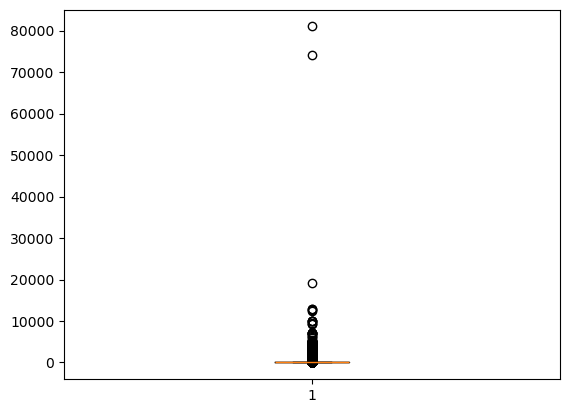

In [23]:
plt.boxplot(s)
plt.show()

In [24]:
q1=df['Quantity'].quantile(0.25) #Lower bound
q1

np.float64(2.0)

In [25]:
q2=df['Quantity'].quantile(0.75)  #upper bound
q2

np.float64(12.0)

In [26]:
h=q2-q1  #IQR:-distance btw upper and lowwer bound
h

np.float64(10.0)

In [27]:
upper=q2+(1.5*h)
upper

np.float64(27.0)

In [28]:
lower=q1-(1.5*h)
lower

np.float64(-13.0)

In [29]:
r=df[(df['Quantity']>upper)|(df['Quantity']<lower)]
r

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
54,489438,21329,DINOSAURS WRITING SET,28,2009-12-01 09:24:00,0.98,18102.0,United Kingdom,27.44
55,489438,21252,SET OF MEADOW FLOWER STICKERS,30,2009-12-01 09:24:00,1.69,18102.0,United Kingdom,50.70
56,489438,21100,CHARLIE AND LOLA CHARLOTTE BAG,30,2009-12-01 09:24:00,1.15,18102.0,United Kingdom,34.50
57,489438,21033,JUMBO BAG CHARLIE AND LOLA TOYS,30,2009-12-01 09:24:00,2.00,18102.0,United Kingdom,60.00
...,...,...,...,...,...,...,...,...,...
1067296,581579,23581,JUMBO BAG PAISLEY PARK,40,2011-12-09 12:19:00,1.79,17581.0,United Kingdom,71.60
1067326,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom,58.00
1067327,581583,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,36,2011-12-09 12:23:00,1.85,13777.0,United Kingdom,66.60
1067328,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom,51.84


In [30]:
actual=df[(df['Quantity']<upper)&(df['Quantity']>lower)]
actual

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [31]:
pp=actual['Quantity']
pp

0          12
1          12
2          12
4          24
5          24
           ..
1067366     6
1067367     4
1067368     4
1067369     3
1067370     1
Name: Quantity, Length: 728178, dtype: int64

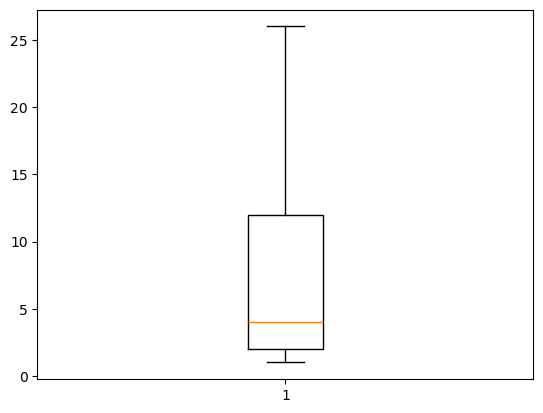

In [32]:
plt.boxplot(pp)
plt.show()      # run outlier remove formula only one time for this column(Quantity).

In [33]:
df['Quantity']=pp

In [34]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [35]:
ss=df['Quantity']

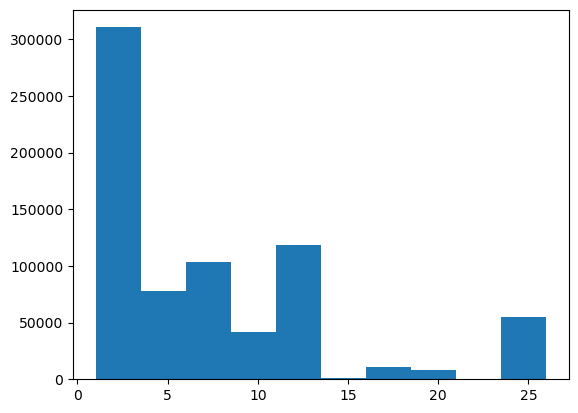

In [36]:
plt.hist(ss)
plt.show()

In [51]:
c=df['Price']
c

0          6.95
1          6.75
2          6.75
3          2.10
4          1.25
           ... 
1067366    2.10
1067367    4.15
1067368    4.15
1067369    4.95
1067370     NaN
Name: Price, Length: 779425, dtype: float64

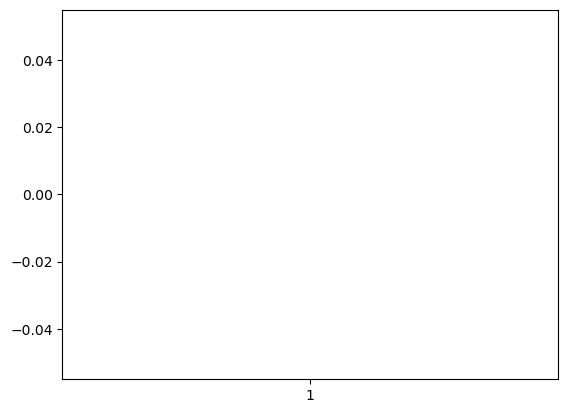

In [52]:
plt.boxplot(c)
plt.show()

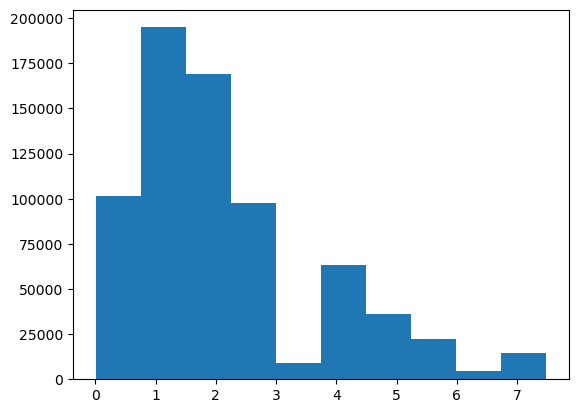

In [53]:
plt.hist(c)
plt.show()

In [54]:
q1=df['Price'].quantile(0.25) #Lower bound
q1

np.float64(1.25)

In [55]:
q2=df['Price'].quantile(0.75)  #upper bound
q2

np.float64(2.95)

In [56]:
h=q2-q1  #IQR:-distance btw upper and lowwer bound
h

np.float64(1.7000000000000002)

In [57]:
upper=q2+(1.5*h)
upper

np.float64(5.5)

In [58]:
lower=q1-(1.5*h)
lower

np.float64(-1.3000000000000003)

In [59]:
r=df[(df['Price']>upper)|(df['Price']<lower)]
r

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10.0,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.50
12,489436,48173C,DOOR MAT BLACK FLOCK,10.0,2009-12-01 09:06:00,5.95,13078.0,United Kingdom,59.50
...,...,...,...,...,...,...,...,...,...
1067203,581571,23110,PARISIENNE KEY CABINET,2.0,2011-12-09 12:00:00,5.75,15311.0,United Kingdom,11.50
1067319,581580,21351,CINAMMON & ORANGE WREATH,1.0,2011-12-09 12:20:00,6.75,12748.0,United Kingdom,6.75
1067322,581580,79321,CHILLI LIGHTS,2.0,2011-12-09 12:20:00,5.75,12748.0,United Kingdom,11.50
1067339,581585,23356,LOVE HOT WATER BOTTLE,3.0,2011-12-09 12:31:00,5.95,15804.0,United Kingdom,17.85


In [60]:
actual=df[(df['Price']<upper)&(df['Price']>lower)]
actual

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24.0,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
8,489435,22350,CAT BOWL,12.0,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60
...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [61]:
ppp=actual['Price']
ppp                     

3          2.10
4          1.25
5          1.65
6          1.25
8          2.55
           ... 
1067365    0.85
1067366    2.10
1067367    4.15
1067368    4.15
1067369    4.95
Name: Price, Length: 674580, dtype: float64

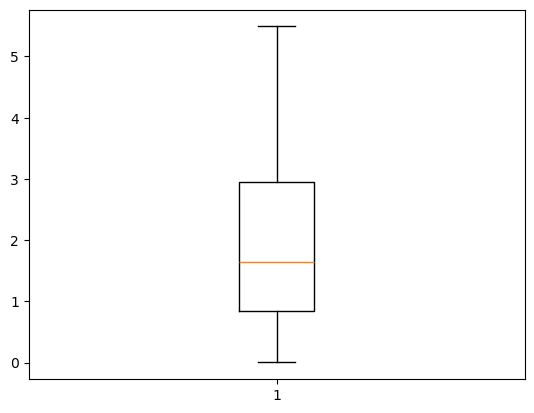

In [62]:
plt.boxplot(ppp)
plt.show()            #run outlier formula two times of this column (Price).

In [63]:
df['Price']=ppp

In [64]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [65]:
x=df['Customer ID']
x

0          13085.0
1          13085.0
2          13085.0
3          13085.0
4          13085.0
            ...   
1067366    12680.0
1067367    12680.0
1067368    12680.0
1067369    12680.0
1067370    12680.0
Name: Customer ID, Length: 779425, dtype: float64

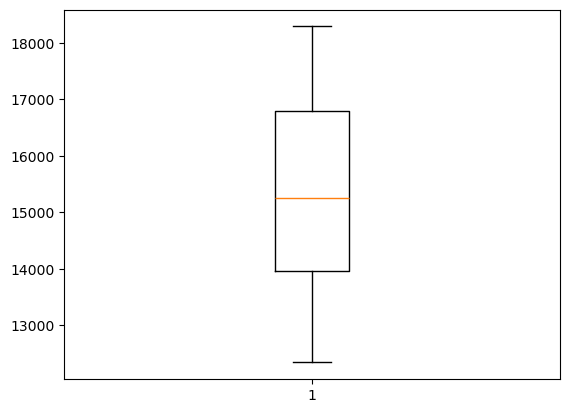

In [66]:
plt.boxplot(x)
plt.show()

In [97]:
t=df['TotalAmount']
t

0            NaN
1            NaN
2            NaN
3            NaN
4          30.00
           ...  
1067366    12.60
1067367    16.60
1067368    16.60
1067369    14.85
1067370    18.00
Name: TotalAmount, Length: 779425, dtype: float64

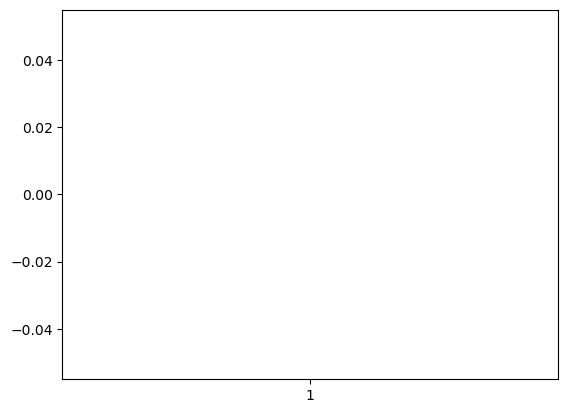

In [98]:
plt.boxplot(t)
plt.show()

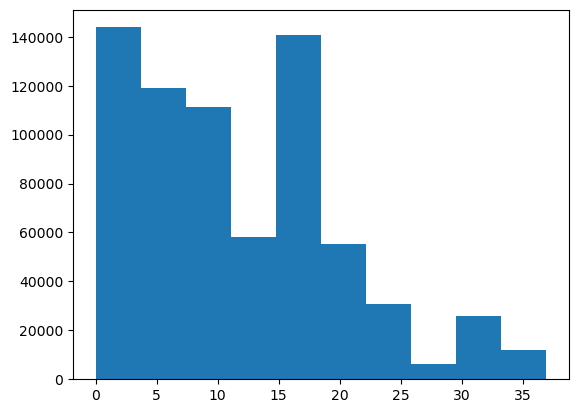

In [99]:
plt.hist(t)
plt.show()

In [100]:
q1=df['TotalAmount'].quantile(0.25) #Lower bound
q1

np.float64(4.25)

In [101]:
q2=df['TotalAmount'].quantile(0.75)  #upper bound
q2

np.float64(17.0)

In [102]:
h=q2-q1  #IQR:-distance btw upper and lowwer bound
h

np.float64(12.75)

In [103]:
upper=q2+(1.5*h)
upper

np.float64(36.125)

In [104]:
lower=q1-(1.5*h)
lower

np.float64(-14.875)

In [105]:
r=df[(df['TotalAmount']>upper)|(df['TotalAmount']<lower)]
r

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
4182,489801,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,NaN,2009-12-02 12:28:00,0.38,12948.0,United Kingdom,36.48
17824,490846,20984,12 PENCILS TALL TUBE POSY,NaN,2009-12-08 12:46:00,0.19,17155.0,United Kingdom,36.48
22213,491149,21007,ETCHED GLASS DROPLET DECORATION,NaN,2009-12-10 08:29:00,0.38,15841.0,United Kingdom,36.48
26889,491674,20707,CRAZY DAISY HEART DECORATION,NaN,2009-12-13 12:04:00,0.38,17593.0,United Kingdom,36.48
33242,492174,21158,MOODY GIRL DOOR HANGER,NaN,2009-12-15 15:16:00,0.38,13798.0,United Kingdom,36.48
...,...,...,...,...,...,...,...,...,...
955387,573576,23264,SET OF 3 WOODEN SLEIGH DECORATIONS,15.0,2011-10-31 14:09:00,2.46,14096.0,United Kingdom,36.90
955390,573576,23272,TREE T-LIGHT HOLDER WILLIE WINKIE,11.0,2011-10-31 14:09:00,3.29,14096.0,United Kingdom,36.19
977089,575219,22338,STAR DECORATION PAINTED ZINC,NaN,2011-11-09 11:17:00,0.19,17511.0,United Kingdom,36.48
1002082,577029,46000S,POLYESTER FILLER PAD 40x40cm,25.0,2011-11-17 12:59:00,1.45,15563.0,United Kingdom,36.25


In [106]:
actual=df[(df['TotalAmount']<upper)&(df['TotalAmount']>lower)]
actual

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
6,489434,21871,SAVE THE PLANET MUG,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
8,489435,22350,CAT BOWL,12.0,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60
11,489435,22353,LUNCHBOX WITH CUTLERY FAIRY CAKES,12.0,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60
14,489436,21754,HOME BUILDING BLOCK WORD,3.0,2009-12-01 09:06:00,NaN,13078.0,United Kingdom,17.85
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [107]:
tt=actual['TotalAmount']    

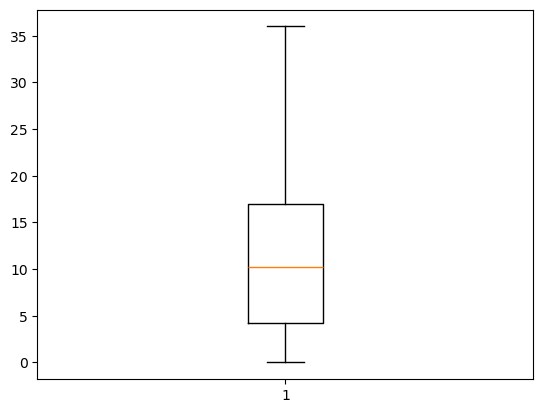

In [108]:
plt.boxplot(tt)
plt.show()             #run outlier remove formula three times for this column(TotalAmount).

In [109]:
df['TotalAmount']=tt

In [110]:
tt=df['TotalAmount']

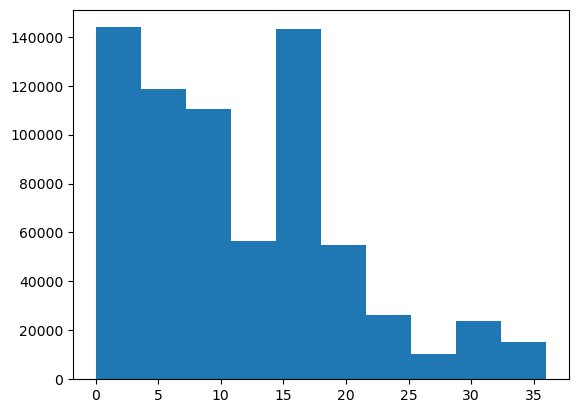

In [111]:
plt.hist(tt)
plt.show()

In [114]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Friday
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011,12,9,12,Friday


In [113]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [116]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

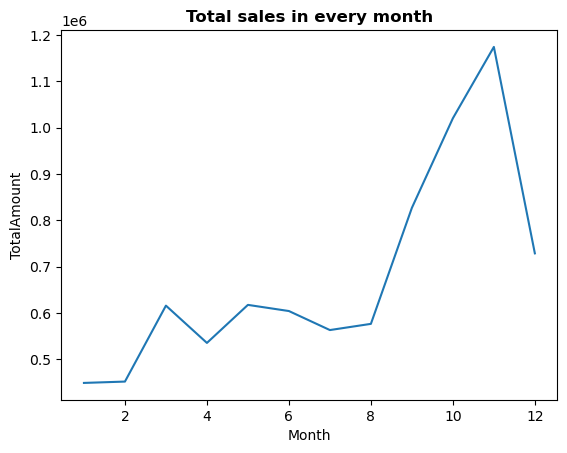

In [117]:
sns.lineplot(monthly_sales,palette='magma')
plt.title("Total sales in every month",fontsize=12,fontweight='bold')
plt.show()

In [118]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

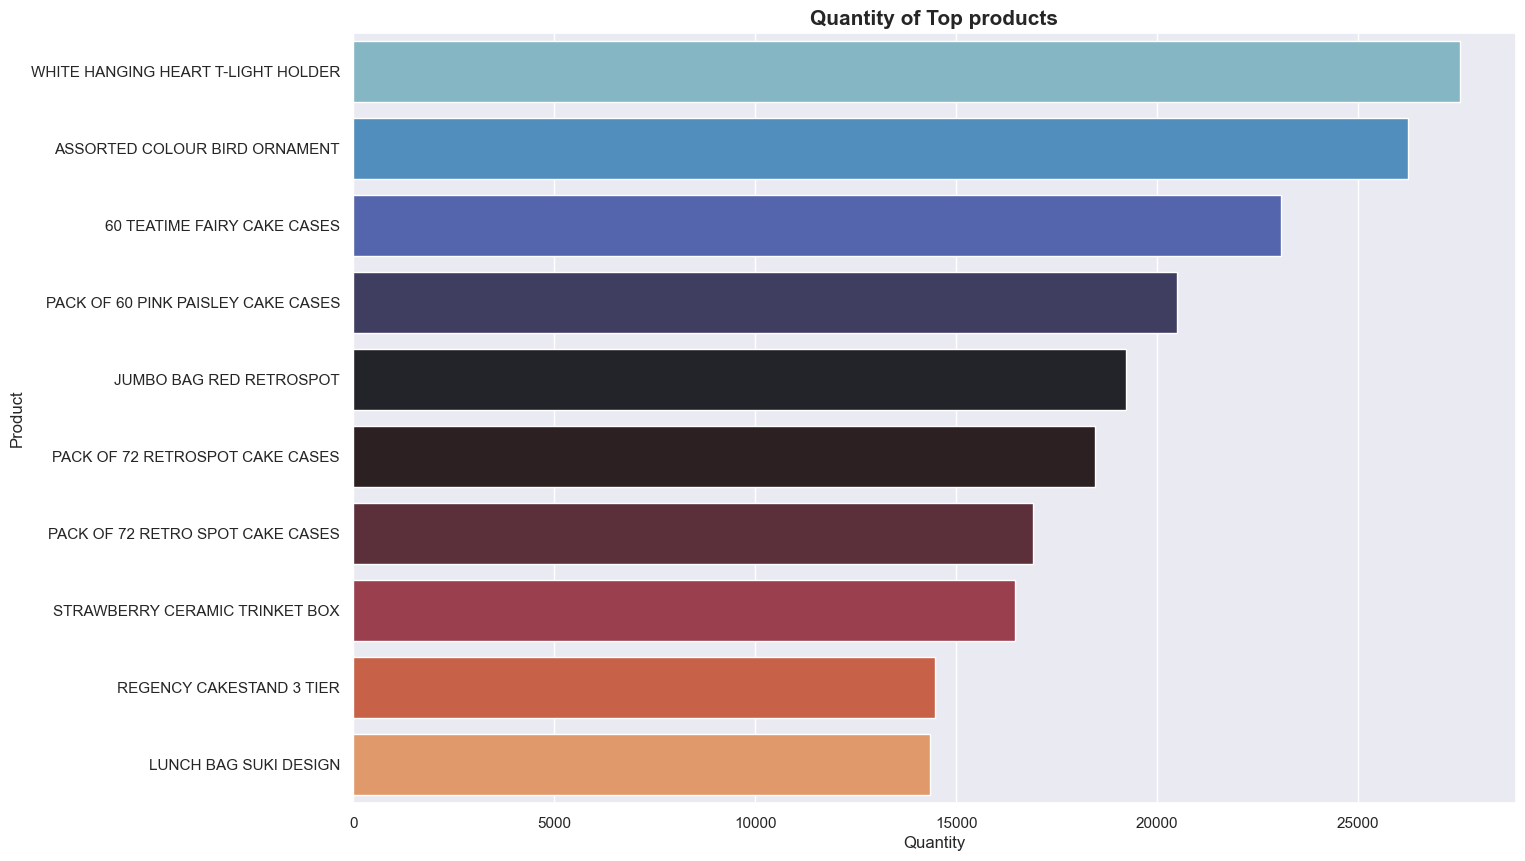

In [119]:
sns.set(rc={'figure.figsize':(15,10)},style='darkgrid')
plt.title("Quantity of Top products",fontsize=15,fontweight='bold')
sns.barplot(y=top_products.index,x=top_products,orient='h',palette='icefire')
plt.xlabel('Quantity')
plt.ylabel("Product")
plt.show()

In [120]:
country_sales = df.groupby('Country')['TotalAmount'].sum()

<Axes: xlabel='Country'>

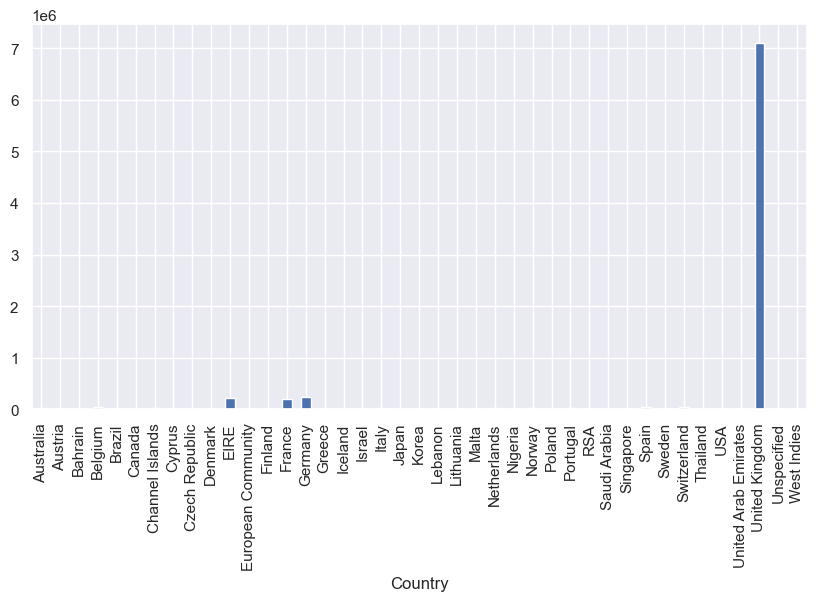

In [121]:
country_sales.plot.bar(figsize=(10,5))

In [122]:
country_sales

Country
Australia                 15714.970
Austria                   13366.700
Bahrain                     921.570
Belgium                   47171.870
Brazil                      684.610
Canada                     3425.380
Channel Islands           24510.500
Cyprus                    14933.320
Czech Republic              339.800
Denmark                    8870.160
EIRE                     217953.880
European Community         1012.250
Finland                   14645.490
France                   191162.820
Germany                  238559.161
Greece                     8644.730
Iceland                    3477.450
Israel                     4235.310
Italy                     22396.560
Japan                      2183.870
Korea                       870.110
Lebanon                     583.130
Lithuania                  2121.860
Malta                      4036.450
Netherlands               27041.940
Nigeria                     140.390
Norway                    17760.120
Poland              

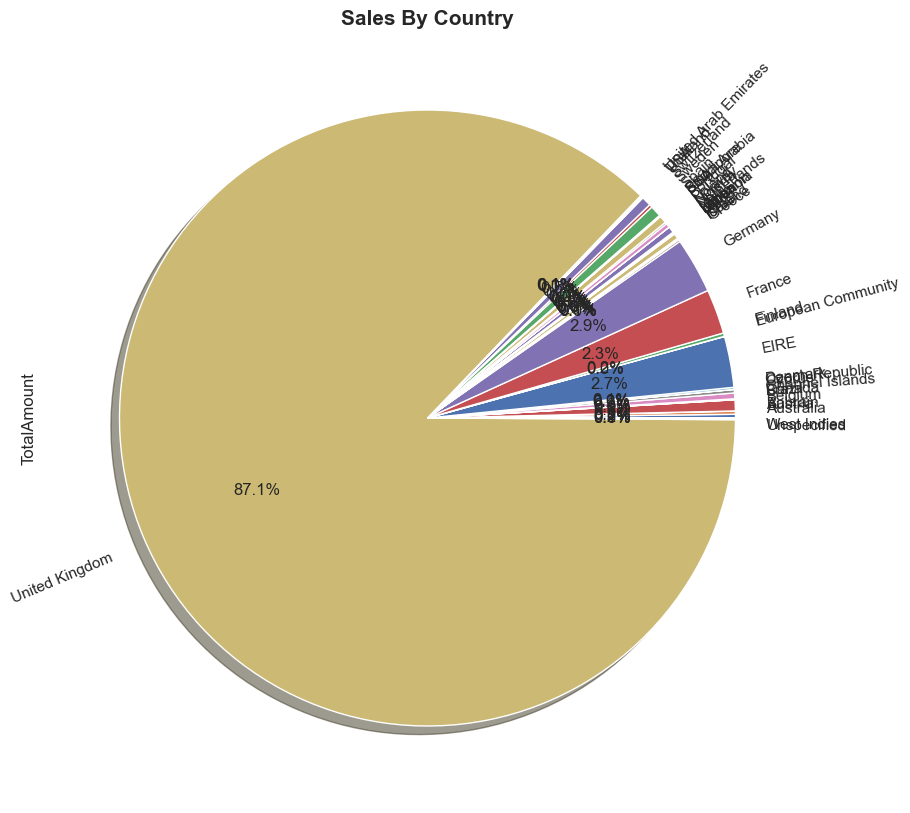

In [123]:
country_sales.plot.pie(autopct='%1.1f%%',shadow=True,rotatelabels=True)
plt.title('Sales By Country',fontweight='bold',fontsize=15)
plt.show()

In [124]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Friday
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011,12,9,12,Friday


In [125]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [126]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [127]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

In [128]:
rfm

,InvoiceDate,Invoice,TotalAmount
Customer ID,,,
12346.0,326,12,327.86
12347.0,2,8,3477.45
12348.0,75,5,333.24
12349.0,19,4,2723.64
12350.0,310,1,294.40
...,...,...,...
18283.0,4,22,2664.90
18284.0,432,1,370.88
18285.0,661,1,173.00


In [129]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [130]:
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,327.86
12347.0,2,8,3477.45
12348.0,75,5,333.24
12349.0,19,4,2723.64
12350.0,310,1,294.40
...,...,...,...
18283.0,4,22,2664.90
18284.0,432,1,370.88
18285.0,661,1,173.00


In [131]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [132]:
rfm

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,327.86,0
12347.0,2,8,3477.45,3
12348.0,75,5,333.24,3
12349.0,19,4,2723.64,3
12350.0,310,1,294.40,0
...,...,...,...,...
18283.0,4,22,2664.90,3
18284.0,432,1,370.88,0
18285.0,661,1,173.00,0


In [133]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum()

In [134]:
daily_sales

InvoiceDate
2009-12-01    22572.18
2009-12-02    19591.91
2009-12-03    26021.21
2009-12-04    18770.62
2009-12-05     6502.34
                ...   
2011-12-05    30136.81
2011-12-06    22291.10
2011-12-07    21245.65
2011-12-08    22571.43
2011-12-09     7438.97
Name: TotalAmount, Length: 604, dtype: float64

<Axes: xlabel='InvoiceDate'>

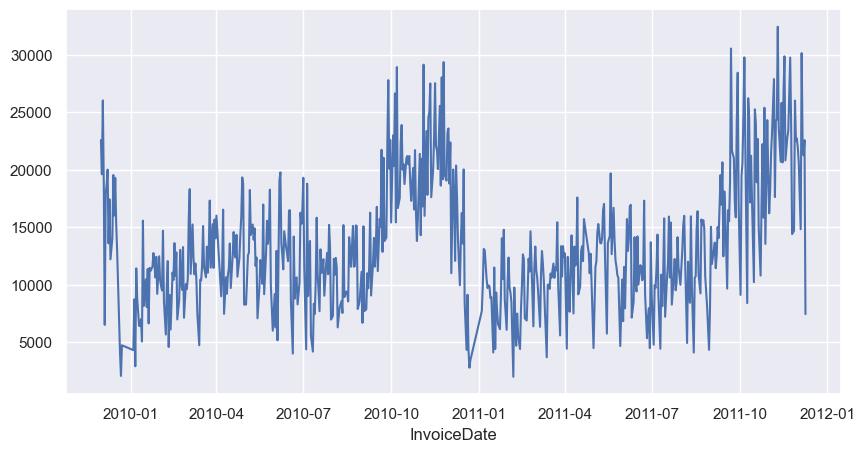

In [135]:
daily_sales.plot.line(figsize=(10,5))

In [136]:
model = ExponentialSmoothing(daily_sales, trend='add')
fit_model = model.fit()
forecast = fit_model.forecast(30)

In [137]:
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

In [138]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [140]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [141]:
pred = model.predict(X_test)

In [142]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [143]:
inventory = df.groupby('Description')['Quantity'].sum()

In [144]:
inventory

Description
10 COLOUR SPACEBOY PEN               8022.0
11 PC CERAMIC TEA SET POLKADOT          3.0
12 ASS ZINC CHRISTMAS DECORATIONS     345.0
12 COLOURED PARTY BALLOONS           3029.0
12 DAISY PEGS IN WOOD BOX             895.0
                                      ...  
ZINC T-LIGHT HOLDER STARS SMALL      2698.0
ZINC TOP 2 DOOR WOODEN SHELF          242.0
ZINC WILLIE WINKIE CANDLE STICK      4732.0
ZINC WIRE KITCHEN ORGANISER            25.0
ZINC WIRE SWEETHEART LETTER TRAY       80.0
Name: Quantity, Length: 5230, dtype: float64

<Axes: xlabel='Description'>

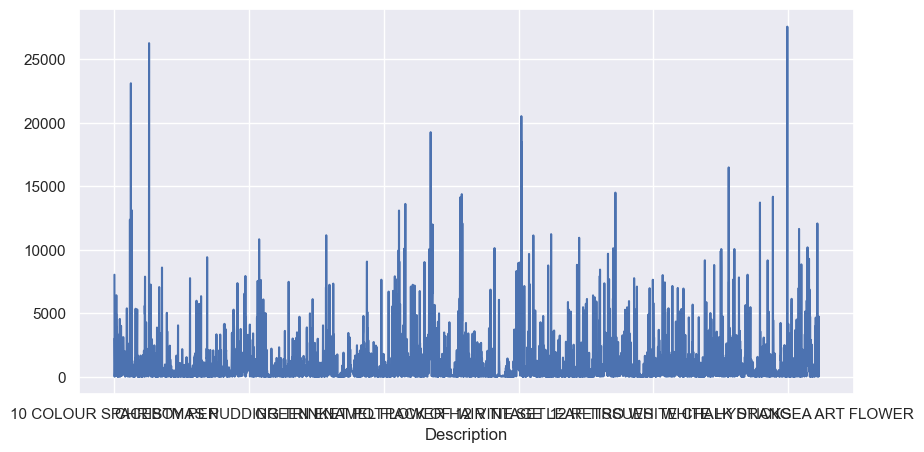

In [145]:
inventory.plot.line(figsize=(10,5)) 

In [146]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,NaN,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",NaN,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,NaN,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Friday
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Friday
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011,12,9,12,Friday


In [147]:
df2=df.select_dtypes(['int','float'])
df2

,Quantity,Price,Customer ID,TotalAmount,Year,Month,Day,Hour
0,12.0,NaN,13085.0,NaN,2009,12,1,7
1,12.0,NaN,13085.0,NaN,2009,12,1,7
2,12.0,NaN,13085.0,NaN,2009,12,1,7
3,NaN,2.10,13085.0,NaN,2009,12,1,7
4,24.0,1.25,13085.0,30.00,2009,12,1,7
...,...,...,...,...,...,...,...,...
1067366,6.0,2.10,12680.0,12.60,2011,12,9,12
1067367,4.0,4.15,12680.0,16.60,2011,12,9,12
1067368,4.0,4.15,12680.0,16.60,2011,12,9,12
1067369,3.0,4.95,12680.0,14.85,2011,12,9,12


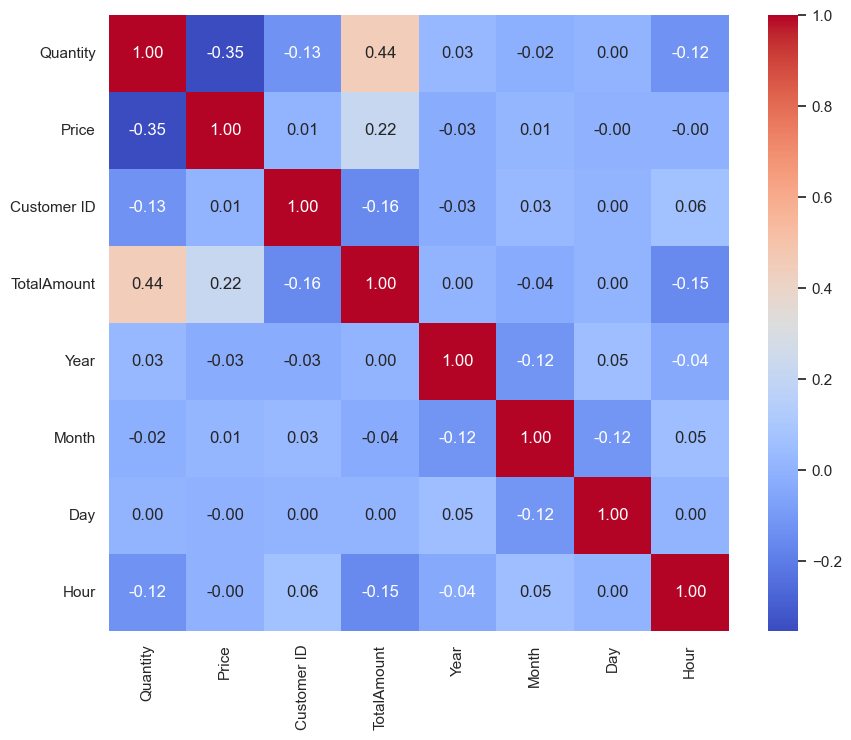

In [148]:
# 1. Calculate the correlation matrix
corr_matrix = df2.corr()

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()